<a href="https://colab.research.google.com/github/BiswajitMallickCSE/Email-Spam-Detection-Using-Multinomial-Naive-Bayes-Classifier/blob/main/Email_Spam_Detection_Using_Multinomial_Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mounting Google Drive**

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Importing Libraries**

In [55]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Loading Dataset**

In [56]:
# Load the dataset
file_path = '/content/drive/MyDrive/spam.csv'
df = pd.read_csv(file_path, encoding='ISO-8859-1')
# Display the first few rows of the dataset
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# **Data Cleaning & Renaming**

In [57]:
# Retain only the necessary columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# **Checking Null Values**

In [58]:
# Check for missing values
df.isnull().sum()

,0
label,0
message,0


# **Data Visualization**

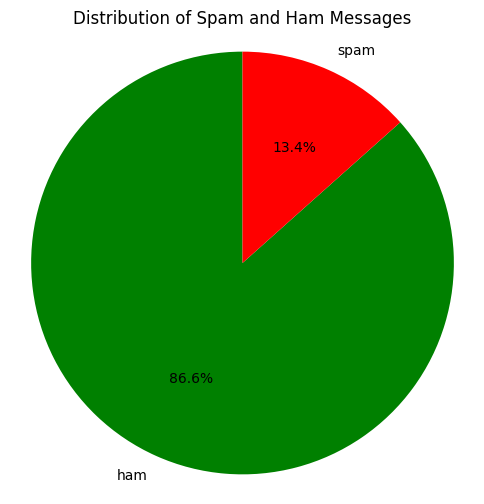

In [59]:
# Plot the distribution of spam and ham messages as a pie chart
labels = df['label'].value_counts().index
sizes = df['label'].value_counts().values

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['Green','Red'])
plt.title('Distribution of Spam and Ham Messages')
plt.axis('equal')  # Ensures the pie chart is circular
plt.show()



# **Feature Extraction**

In [60]:
# Convert text data to numerical data
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label'].map({'ham': 0, 'spam': 1})


# **Train-Test Split**

In [61]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **Training the Naive Bayes Model**

In [62]:
# Train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)



MultinomialNB()

# **Model Evaluation & Metrics**

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import log_loss

y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

conf_matrix = confusion_matrix(y_test, y_test_pred)
class_report = classification_report(y_test, y_test_pred)


train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_loss = log_loss(y_train, y_train_pred)
test_loss = log_loss(y_test, y_test_pred)

print(f'Training Accuracy: {train_accuracy}')
print(f'Test Accuracy: {test_accuracy}')
print(f'Training Loss: {train_loss}')
print(f'Test Loss: {test_loss}')

Training Accuracy: 0.9943908458604442
Test Accuracy: 0.97847533632287
Training Loss: 0.2021744076122795
Test Loss: 0.7758275168957954


# **Confusion Matrix & Heatmap**


Confusion Matrix:
                   Predicted Legal_Mail  Predicted Junk_Mail
Actual Legal_Mail                   952                   13
Actual Junk_Mail                     11                  139


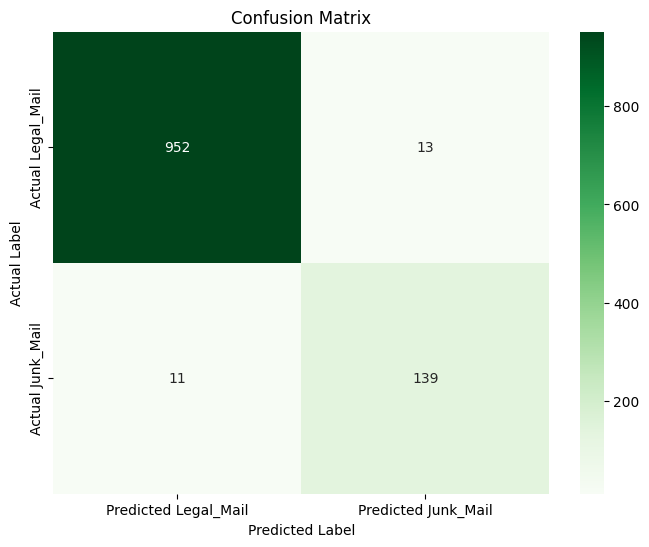

In [64]:
conf_matrix_df = pd.DataFrame(conf_matrix, index=['Actual Legal_Mail', 'Actual Junk_Mail'], columns=['Predicted Legal_Mail', 'Predicted Junk_Mail'])

print("\nConfusion Matrix:")
print(conf_matrix_df)

#Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# **Classification Report**


Classification Report (Text):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



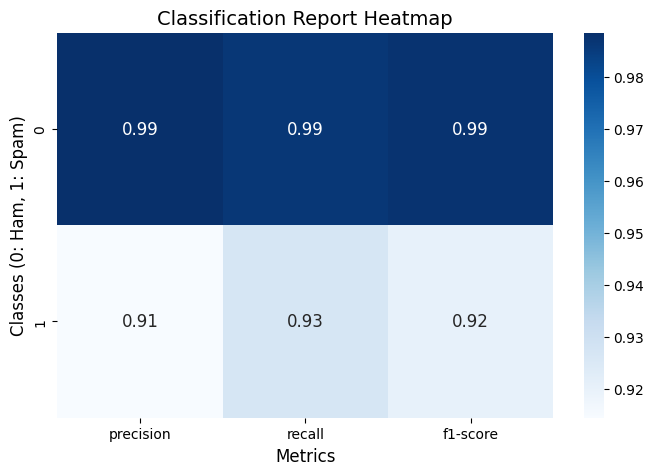

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
class_report_dict = classification_report(y_test, y_test_pred, output_dict=True)
class_report_text = classification_report(y_test, y_test_pred)
print("\nClassification Report (Text):")
print(class_report_text)

def plot_classification_report(class_report_dict):
    report_df = pd.DataFrame(class_report_dict).transpose()
    plot_data = report_df.drop(index=['accuracy', 'macro avg', 'weighted avg']).drop(columns=['support'])
    plt.figure(figsize=(8, 5))
    sns.heatmap(plot_data, annot=True, cmap='Blues', fmt='.2f', annot_kws={"size": 12})
    plt.title('Classification Report Heatmap', fontsize=14)
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Classes (0: Ham, 1: Spam)', fontsize=12)
    plt.show()
plot_classification_report(class_report_dict)